In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
ratings = pd.read_csv("recomdata/ratings.csv")
movies = pd.read_csv("recomdata/movies.csv")

print("Ratings shape:", ratings.shape)
print("Unique users:", ratings.userId.nunique())
print("Unique movies:", ratings.movieId.nunique())


Ratings shape: (100836, 4)
Unique users: 610
Unique movies: 9724


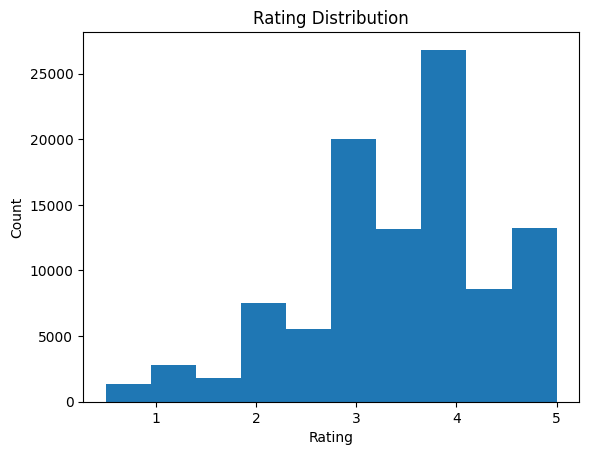

In [24]:
plt.hist(ratings['rating'], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


In [25]:
ratings = ratings.sample(frac=1, random_state=42)

split = int(0.8 * len(ratings))

train = ratings.iloc[:split]
test  = ratings.iloc[split:]

print("Train size:", train.shape)
print("Test size:", test.shape)


Train size: (80668, 4)
Test size: (20168, 4)


In [26]:
R_train = train.pivot(index='userId',
                      columns='movieId',
                      values='rating').fillna(0)

R_matrix = R_train.values


In [27]:
user_ids = list(R_train.index)
movie_ids = list(R_train.columns)

user_map = {uid: idx for idx, uid in enumerate(user_ids)}
movie_map = {mid: idx for idx, mid in enumerate(movie_ids)}


Sparsity: 0.9851878782537165


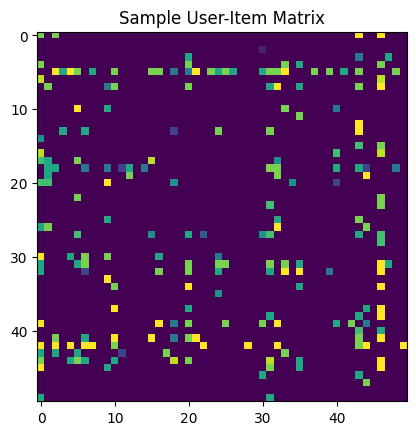

In [28]:
sparsity = 1.0 - np.count_nonzero(R_matrix) / R_matrix.size
print("Sparsity:", sparsity)

plt.imshow(R_matrix[:50, :50])
plt.title("Sample User-Item Matrix")
plt.show()


In [29]:
def cosine_similarity_matrix(X):
    dot_product = X @ X.T
    norms = np.linalg.norm(X, axis=1)
    norm_matrix = np.outer(norms, norms)
    return dot_product / (norm_matrix + 1e-8)


In [30]:
def predict_user_cf(R):
    
    mean_user = np.sum(R, axis=1) / (np.count_nonzero(R, axis=1) + 1e-8)
    R_diff = R - mean_user.reshape(-1,1)
    
    similarity = cosine_similarity_matrix(R_diff)
    
    numerator = similarity @ R_diff
    denominator = np.abs(similarity).sum(axis=1).reshape(-1,1)
    
    pred = mean_user.reshape(-1,1) + numerator / (denominator + 1e-8)
    
    return pred

user_pred = predict_user_cf(R_matrix)


In [31]:
def predict_item_cf(R):
    
    similarity = cosine_similarity_matrix(R.T)
    
    numerator = R @ similarity
    denominator = np.abs(similarity).sum(axis=1)
    
    return numerator / (denominator + 1e-8)

item_pred = predict_item_cf(R_matrix)


In [34]:
class MatrixFactorization:
    
    def __init__(self, R, k=20, lr=0.01, reg=0.1, epochs=50):
        self.R = R
        self.num_users, self.num_items = R.shape
        self.k = k
        self.lr = lr
        self.reg = reg
        self.epochs = epochs
        
        self.P = np.random.normal(scale=1./k,
                                  size=(self.num_users, k))
        self.Q = np.random.normal(scale=1./k,
                                  size=(self.num_items, k))
    
    def train(self):
        self.losses = []
        
        for epoch in range(self.epochs):
            total_loss = 0
            
            for u in range(self.num_users):
                for i in range(self.num_items):
                    if self.R[u, i] > 0:
                        
                        pred = self.P[u] @ self.Q[i]
                        error = self.R[u, i] - pred
                        
                        total_loss += error**2
                        
                        self.P[u] += self.lr * (error * self.Q[i] - self.reg * self.P[u])
                        self.Q[i] += self.lr * (error * self.P[u] - self.reg * self.Q[i])
            
            self.losses.append(total_loss)
            print("Epoch", epoch, "Loss:", total_loss)
    
    def predict(self):
        return self.P @ self.Q.T


In [35]:
mf = MatrixFactorization(R_matrix)
mf.train()
mf_pred = mf.predict()


Epoch 0 Loss: 968425.007689706
Epoch 1 Loss: 455085.8887777612
Epoch 2 Loss: 193903.11775442734
Epoch 3 Loss: 129585.78467128816
Epoch 4 Loss: 104341.63779500591
Epoch 5 Loss: 90854.7193333615
Epoch 6 Loss: 82413.11344394564
Epoch 7 Loss: 76569.78331634878
Epoch 8 Loss: 72238.07710881924
Epoch 9 Loss: 68870.07058872122
Epoch 10 Loss: 66160.91206351826
Epoch 11 Loss: 63924.2156396055
Epoch 12 Loss: 62034.63646546192
Epoch 13 Loss: 60401.72193185336
Epoch 14 Loss: 58958.43101243489
Epoch 15 Loss: 57655.31670263572
Epoch 16 Loss: 56456.484986060306
Epoch 17 Loss: 55336.32600723309
Epoch 18 Loss: 54276.90317032768
Epoch 19 Loss: 53265.93117174629
Epoch 20 Loss: 52295.21417826122
Epoch 21 Loss: 51359.425598086156
Epoch 22 Loss: 50455.156989184856
Epoch 23 Loss: 49580.199746690494
Epoch 24 Loss: 48733.034522601476
Epoch 25 Loss: 47912.497813862195
Epoch 26 Loss: 47117.58693560768
Epoch 27 Loss: 46347.36251156163
Epoch 28 Loss: 45600.91256374572
Epoch 29 Loss: 44877.35074815279
Epoch 30 Loss:

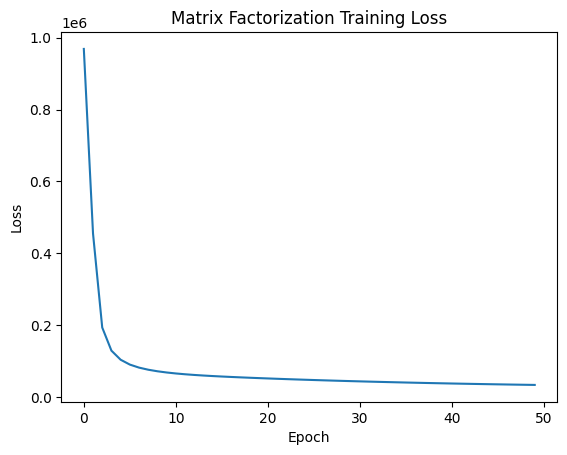

In [36]:
plt.plot(mf.losses)
plt.title("Matrix Factorization Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [37]:
def rmse(pred_matrix, test_df):
    
    errors = []
    
    for row in test_df.itertuples():
        u = user_map.get(row.userId)
        i = movie_map.get(row.movieId)
        
        if u is not None and i is not None:
            errors.append((row.rating - pred_matrix[u, i])**2)
    
    return np.sqrt(np.mean(errors))

print("User CF RMSE:", rmse(user_pred, test))
print("Item CF RMSE:", rmse(item_pred, test))
print("Matrix Factorization RMSE:", rmse(mf_pred, test))


User CF RMSE: 3.498909717789897
Item CF RMSE: 3.3741062082197733
Matrix Factorization RMSE: 0.8886218777077028


In [38]:
def recommend(pred_matrix, user_id, top_n=5):
    
    if user_id not in user_map:
        return "User not in training set"
    
    user_index = user_map[user_id]
    user_predictions = pred_matrix[user_index].copy()
    
    rated = R_matrix[user_index] > 0
    user_predictions[rated] = -999
    
    top_indices = np.argsort(user_predictions)[-top_n:]
    
    recommended_movie_ids = [movie_ids[i] for i in top_indices]
    
    return movies[movies.movieId.isin(recommended_movie_ids)][["movieId","title"]]


In [39]:
recommend(mf_pred, user_id=1, top_n=5)


,movieId,title
2279,3022,"General, The (1926)"
4390,6442,Belle époque (1992)
4396,6460,"Trial, The (Procès, Le) (1962)"
4782,7121,Adam's Rib (1949)
5202,8477,"Jetée, La (1962)"
